#CLUSTERING

##Carga de librerías

In [ ]:
!pip install pyarrow -q

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
import matplotlib.pyplot as plt

###Librerías adicionales para comparación de modelos

Se añaden librerías adicionales para probar otros algoritmos de clustering y comparar resultados.

In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering

##Carga de datos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = '/content/drive/MyDrive/TFM/df_final_preparado_3.parquet'
df = pd.read_parquet(path,engine='pyarrow')

In [ ]:

print("Shape del dataset:", df.shape)
df.head()

Shape del dataset: (5961849, 44)


,pk_partition_year,pk_partition_month,entry_date_year,entry_date_month,pk_cid_n,age_n,salary_n,net_margin_n,region_code_cat_8.0,region_code_cat_15.0,...,securities_b,long_term_deposit_b,credit_card_b,payroll_b,pension_plan_b,payroll_account_b,emc_account_b,debit_card_b,em_account_p_b,em_acount_b
0,2018,1,2018,1,1375586.0,35.0,87218.101562,0.0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2018,1,2015,8,1050611.0,23.0,35548.738281,0.0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,2018,1,2015,8,1050612.0,23.0,122179.109375,0.0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,2018,1,2015,8,1050613.0,22.0,119775.539062,0.0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2018,1,2015,8,1050614.0,23.0,88441.468750,0.0,0,0,...,0,0,0,0,0,0,0,0,0,1


##Selección de la muestra para clustering

In [ ]:
df_cluster = df[
    (df['pk_partition_year'] == 2019) &
    (df['pk_partition_month'] == 5)
].copy()

df_cluster = df_cluster[df_cluster['active_customer_b'] == 1].copy()

print("Shape tras filtrar mayo 2019 y clientes activos:", df_cluster.shape)

Shape tras filtrar mayo 2019 y clientes activos: (171514, 44)


Se filtra la última fotografía disponible, mayo de 2019, y se trabaja únicamente con clientes activos. Esto permite obtener segmentos más útiles desde el punto de vista comercial, evitando que el algoritmo se limite a separar clientes activos e inactivos.

###Selección de variables

In [ ]:
features = [
    'age_n',
    'salary_n',
    'net_margin_n',
    'credit_card_b',
    'payroll_b',
    'pension_plan_b',
    'debit_card_b',
    'em_acount_b',
    'payroll_account_b',
    'emc_account_b',
    'funds_b',
    'securities_b',
    'long_term_deposit_b',
    'segment_cat_02 - PARTICULARES',
    'segment_cat_03 - UNIVERSITARIO',
    'segment_cat_Other'
]

X = df_cluster[features].copy()
X.head()

,age_n,salary_n,net_margin_n,credit_card_b,payroll_b,pension_plan_b,debit_card_b,em_acount_b,payroll_account_b,emc_account_b,funds_b,securities_b,long_term_deposit_b,segment_cat_02 - PARTICULARES,segment_cat_03 - UNIVERSITARIO,segment_cat_Other
5519929,44.0,54493.378906,0.0,0,0,0,0,1,0,0,0,0,0,1,0,0
5519931,39.0,100993.171875,0.0,1,1,1,1,0,1,1,0,0,0,1,0,0
5519932,85.0,154059.093750,0.0,0,0,0,0,1,0,0,0,0,1,0,0,0
5519933,38.0,88441.468750,0.0,0,0,0,0,1,0,0,0,0,0,1,0,0
5519935,42.0,183036.718750,0.0,1,1,1,1,0,1,1,0,0,0,1,0,0


Se seleccionan variables demográficas, económicas, de productos y de segmento comercial. Se elimina active_customer_b porque el análisis ya se limita a clientes activos, evitando que esta variable domine la separación de los clusters.

In [ ]:
constant_cols = [col for col in X.columns if X[col].nunique() <= 1]

constant_cols

[]

In [ ]:
X = X.drop(columns=constant_cols)

features = X.columns.tolist()

print("Variables eliminadas por ser constantes:", constant_cols)
print("Variables finales utilizadas:", features)

Variables eliminadas por ser constantes: []
Variables finales utilizadas: ['age_n', 'salary_n', 'net_margin_n', 'credit_card_b', 'payroll_b', 'pension_plan_b', 'debit_card_b', 'em_acount_b', 'payroll_account_b', 'emc_account_b', 'funds_b', 'securities_b', 'long_term_deposit_b', 'segment_cat_02 - PARTICULARES', 'segment_cat_03 - UNIVERSITARIO', 'segment_cat_Other']


Se revisan las variables constantes, es decir, aquellas que tienen el mismo valor para todos los clientes. Estas variables no aportan información al clustering y se eliminan del modelo.

###Escalado de variables

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

###Validación del número de clusters: método del codo

Se incorpora el **método del codo** para justificar el número de clusters. Esta técnica permite observar cómo disminuye la inercia al aumentar el número de grupos y seleccionar un punto razonable donde añadir más clusters deja de aportar una mejora significativa.

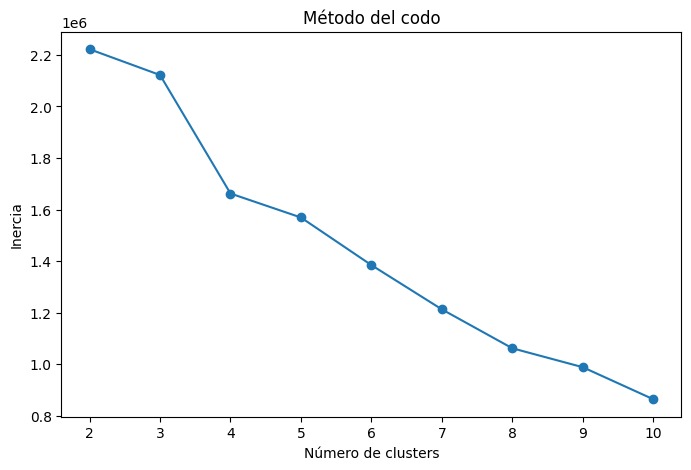

In [ ]:
inertias = []
K = range(2, 11)

for k in K:
    model = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        batch_size=10000,
        n_init=10
    )
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertias, marker='o')
plt.title('Método del codo')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.show()

**Interpretación:**  
El objetivo de este gráfico es identificar un punto a partir del cual aumentar el número de clusters apenas reduce la inercia. Ese punto se interpreta como un equilibrio entre detalle e interpretabilidad de los grupos.

In [ ]:
for k in [5, 7, 8]:
    model = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        batch_size=10000,
        n_init=10
    )

    df_cluster[f'cluster_{k}'] = model.fit_predict(X_scaled)

    print(f"\nDistribución para {k} clusters:")
    print(df_cluster[f'cluster_{k}'].value_counts(normalize=True).sort_index().round(3))


Distribución para 5 clusters:
cluster_5
0    0.336
1    0.132
2    0.423
3    0.009
4    0.100
Name: proportion, dtype: float64

Distribución para 7 clusters:
cluster_7
0    0.440
1    0.421
2    0.087
3    0.026
4    0.009
5    0.008
6    0.010
Name: proportion, dtype: float64

Distribución para 8 clusters:
cluster_8
0    0.421
1    0.081
2    0.417
3    0.009
4    0.007
5    0.027
6    0.032
7    0.008
Name: proportion, dtype: float64


Además del método del codo, se prueban configuraciones de 5, 7 y 8 clusters, ya que el enunciado sugería trabajar con un número mayor de segmentos. Esto permite comparar la interpretabilidad y distribución de los grupos antes de elegir el modelo final.

###Distribución de clusters

In [ ]:
cluster_counts = df_cluster['cluster_5'].value_counts().sort_index()
cluster_counts

,count
cluster_5,
0,57584
1,22696
2,72521
3,1508
4,17205


###Visualización de clusters

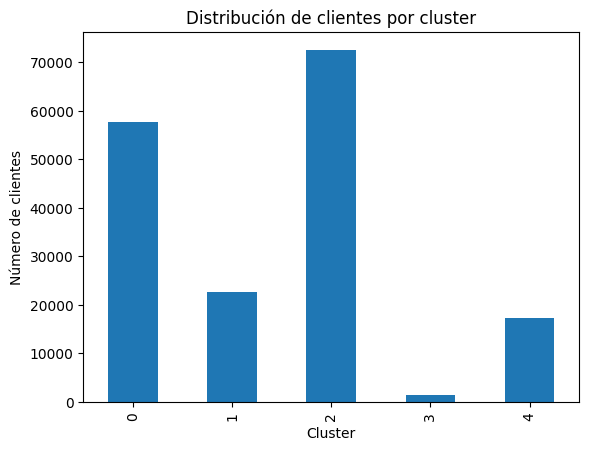

In [ ]:
cluster_counts.plot(kind='bar')
plt.title("Distribución de clientes por cluster")
plt.xlabel("Cluster")
plt.ylabel("Número de clientes")
plt.show()

###Perfilado de clusters

In [ ]:
perfil_clusters = df_cluster.groupby('cluster_5')[features].mean().round(2)

perfil_clusters

,age_n,salary_n,net_margin_n,credit_card_b,payroll_b,pension_plan_b,debit_card_b,em_acount_b,payroll_account_b,emc_account_b,funds_b,securities_b,long_term_deposit_b,segment_cat_02 - PARTICULARES,segment_cat_03 - UNIVERSITARIO,segment_cat_Other
cluster_5,,,,,,,,,,,,,,,,
0,43.630001,100874.632812,3.310000,0.02,0.00,0.00,0.00,0.78,0.05,0.22,0.02,0.02,0.09,0.90,0.00,0.0
1,41.220001,97509.718750,4.390000,0.06,0.00,0.00,1.00,0.82,0.15,0.15,0.00,0.02,0.01,0.97,0.01,0.0
2,23.799999,98478.562500,0.680000,0.00,0.00,0.00,0.12,0.94,0.04,0.02,0.00,0.00,0.00,0.00,1.00,0.0
3,40.970001,88594.968750,164.369995,0.00,0.02,0.02,0.03,0.88,0.01,0.01,0.00,0.00,0.00,0.00,0.00,1.0
4,37.259998,100228.343750,427.559998,0.12,0.95,1.00,0.64,0.08,0.94,0.23,0.01,0.02,0.02,0.67,0.29,0.0


###Interpretación de los clusters

El análisis de clustering ha permitido identificar **cinco segmentos de clientes** con comportamientos claramente diferenciados. La principal separación entre grupos no viene dada por el salario, que presenta valores muy similares entre clusters, sino por variables relacionadas con la edad, el nivel de actividad, el margen generado y la contratación de productos.

En primer lugar, se identifican dos grupos de baja vinculación: un segmento de clientes maduros con poca actividad (Cluster 0) y otro de clientes jóvenes con una relación muy básica con la entidad (Cluster 1). Ambos presentan un bajo nivel de rentabilidad y una escasa penetración de productos.

Por otro lado, el Cluster 2 concentra a los clientes de mayor valor, con el margen neto más elevado y una fuerte presencia de productos como nómina y plan de pensiones, lo que indica una alta vinculación comercial. El Cluster 3 representa clientes activos con un uso más transaccional de la entidad, especialmente a través de débito y cuenta, mientras que el Cluster 4 agrupa clientes activos pero todavía muy básicos, con margen reducido y poca diversificación de productos.

Desde el punto de vista de negocio, esta segmentación permite diseñar estrategias diferenciadas según el perfil de cliente: acciones de activación en los segmentos menos vinculados, campañas de cross-selling en los clusters activos básicos y estrategias de fidelización y retención en los clientes de mayor valor.

###Asignación de nombres de negocio a los clusters

Una vez interpretados los clusters, se asignan nombres descriptivos basados en las características principales de cada grupo. Esto permite traducir los resultados técnicos del modelo a segmentos comprensibles desde el punto de vista de negocio.

In [ ]:
cluster_names = {
    0: 'Clientes maduros de baja vinculación',
    1: 'Clientes jóvenes básicos',
    2: 'Clientes de alto valor y alta vinculación',
    3: 'Clientes activos transaccionales',
    4: 'Clientes activos básicos con cuenta'
}

df_cluster['cluster_name'] = df_cluster['cluster_5'].map(cluster_names)

df_cluster[['cluster_5', 'cluster_name']].drop_duplicates().sort_values('cluster_5')

,cluster_5,cluster_name
5519929,0,Clientes maduros de baja vinculación
5519939,1,Clientes jóvenes básicos
5520059,2,Clientes de alto valor y alta vinculación
5520023,3,Clientes activos transaccionales
5519931,4,Clientes activos básicos con cuenta


###Distribución de clientes por segmento de negocio

Se analiza cuántos clientes hay en cada segmento ya con nombres de negocio, lo que facilita la lectura de resultados para una audiencia no técnica.

In [ ]:
df_cluster['cluster_name'].value_counts()

,count
cluster_name,
Clientes de alto valor y alta vinculación,72521
Clientes maduros de baja vinculación,57584
Clientes jóvenes básicos,22696
Clientes activos básicos con cuenta,17205
Clientes activos transaccionales,1508


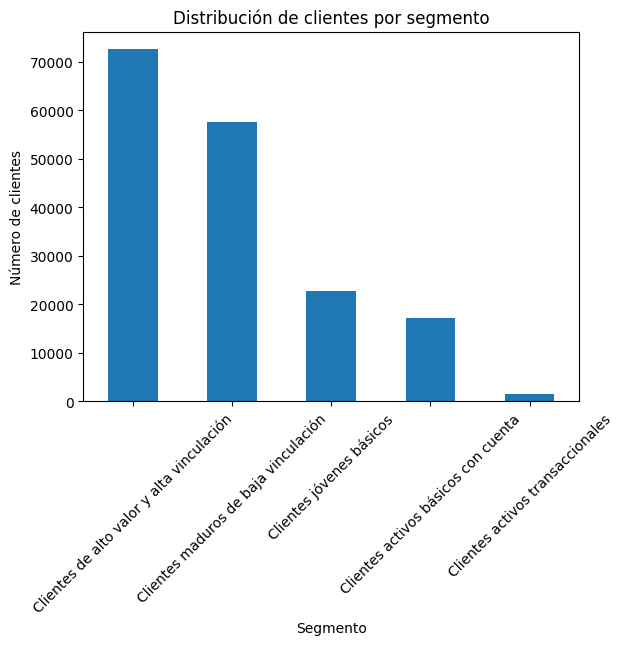

In [ ]:
df_cluster['cluster_name'].value_counts().plot(kind='bar')
plt.title("Distribución de clientes por segmento")
plt.xlabel("Segmento")
plt.ylabel("Número de clientes")
plt.xticks(rotation=45)
plt.show()

###Prueba con más variables

Se realiza una segunda prueba incorporando más variables relacionadas con productos financieros. El objetivo es comprobar si al añadir más información sobre el cliente los grupos cambian o se mantienen estables.

In [ ]:
features_v2 = [
    'age_n',
    'salary_n',
    'net_margin_n',
    'credit_card_b',
    'payroll_b',
    'pension_plan_b',
    'debit_card_b',
    'em_acount_b',
    'mortgage_b',
    'funds_b',
    'securities_b',
    'long_term_deposit_b',
    'payroll_account_b',
    'emc_account_b'
]

# Nos quedamos solo con las variables que existan en el dataset, por seguridad
features_v2 = [col for col in features_v2 if col in df_cluster.columns]

X_v2 = df_cluster[features_v2].copy()

X_v2.head()

,age_n,salary_n,net_margin_n,credit_card_b,payroll_b,pension_plan_b,debit_card_b,em_acount_b,mortgage_b,funds_b,securities_b,long_term_deposit_b,payroll_account_b,emc_account_b
5519929,44.0,54493.378906,0.0,0,0,0,0,1,0,0,0,0,0,0
5519931,39.0,100993.171875,0.0,1,1,1,1,0,0,0,0,0,1,1
5519932,85.0,154059.093750,0.0,0,0,0,0,1,0,0,0,1,0,0
5519933,38.0,88441.468750,0.0,0,0,0,0,1,0,0,0,0,0,0
5519935,42.0,183036.718750,0.0,1,1,1,1,0,0,0,0,0,1,1


###Escalado de variables ampliadas

Al igual que en el modelo inicial, se escalan las variables para evitar que unas tengan más peso que otras por su magnitud.

In [ ]:
scaler_v2 = StandardScaler()
X_v2_scaled = scaler_v2.fit_transform(X_v2)

###Método del codo con variables ampliadas

Se repite el método del codo utilizando la selección ampliada de variables para comprobar si la incorporación de nuevos productos financieros modifica la estructura de clusters.

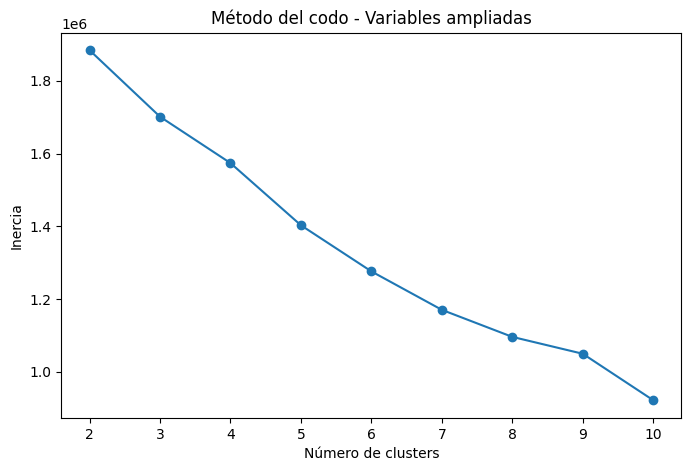

In [ ]:
inertias_v2 = []
K = range(2, 11)

for k in K:
    model = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        batch_size=10000,
        n_init=10
    )
    model.fit(X_v2_scaled)
    inertias_v2.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertias_v2, marker='o')
plt.title('Método del codo - Variables ampliadas')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.show()

###Modelo alternativo con variables ampliadas

Se entrena un segundo modelo de clustering con el conjunto ampliado de variables. Esta prueba permite comprobar si los segmentos obtenidos son similares o si cambian al incluir más información comercial.

In [ ]:
k_final = 5

kmeans_final = MiniBatchKMeans(
    n_clusters=k_final,
    random_state=42,
    batch_size=10000,
    n_init=10
)

df_cluster['cluster'] = kmeans_final.fit_predict(X_v2_scaled)

df_cluster['cluster'].value_counts().sort_index()

,count
cluster,
0,5773
1,98975
2,16791
3,48193
4,1782


###Perfilado del modelo con variables ampliadas

Se perfila el segundo modelo calculando los valores medios de las variables en cada cluster. Esto permite interpretar los nuevos segmentos y compararlos con los obtenidos en el modelo inicial.

In [ ]:
perfil_clusters = df_cluster.groupby('cluster')[features_v2].mean().round(2)

perfil_clusters

,age_n,salary_n,net_margin_n,credit_card_b,payroll_b,pension_plan_b,debit_card_b,em_acount_b,mortgage_b,funds_b,securities_b,long_term_deposit_b,payroll_account_b,emc_account_b
cluster,,,,,,,,,,,,,,
0,53.750000,115822.453125,6.540000,0.03,0.02,0.02,0.09,0.67,0.0,0.06,0.0,1.00,0.06,0.38
1,26.590000,95918.382812,1.550000,0.00,0.00,0.00,0.10,0.95,0.0,0.00,0.0,0.00,0.02,0.00
2,37.040001,99883.976562,441.750000,0.11,0.95,1.00,0.64,0.07,0.0,0.01,0.0,0.01,0.94,0.22
3,46.320000,103324.007812,4.670000,0.05,0.00,0.00,0.44,0.72,0.0,0.01,0.0,0.00,0.15,0.31
4,44.950001,113821.257812,61.900002,0.11,0.16,0.18,0.40,0.77,0.0,0.09,1.0,0.07,0.20,0.37


###Comparación entre modelo inicial y modelo ampliado

Se compara la asignación de clientes entre el modelo inicial y el modelo con variables ampliadas. El objetivo es analizar si los grupos son estables o si cambian de forma significativa al modificar las variables utilizadas.

In [ ]:
comparacion_clusters = pd.crosstab(
    df_cluster['cluster'],
    df_cluster['cluster_5'],
    normalize='index'
).round(2)

comparacion_clusters

cluster_5,0,1,2,3,4
cluster,,,,,
0,0.91,0.04,0.02,0.00,0.02
1,0.27,0.03,0.69,0.01,0.00
2,0.00,0.00,0.00,0.00,1.00
3,0.52,0.40,0.07,0.01,0.00
4,0.51,0.24,0.08,0.00,0.17


###Comparación con otros modelos de clustering

Además de MiniBatchKMeans, se prueban otros algoritmos para comprobar si la segmentación es razonablemente consistente.

###Prueba con KMeans tradicional

Se prueba KMeans tradicional para comparar los resultados con MiniBatchKMeans. Ambos algoritmos siguen una lógica similar, pero MiniBatchKMeans está optimizado para trabajar con datasets de mayor tamaño.

In [ ]:
kmeans_tradicional = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df_cluster['cluster_kmeans'] = kmeans_tradicional.fit_predict(X_v2_scaled)

df_cluster['cluster_kmeans'].value_counts().sort_index()

,count
cluster_kmeans,
0,121119
1,32091
2,15849
3,1145
4,1310


###Perfilado de KMeans tradicional

Se analizan las características medias de los clusters obtenidos con KMeans tradicional para compararlas con el modelo principal.

In [ ]:
perfil_kmeans = df_cluster.groupby('cluster_kmeans')[features_v2].mean().round(2)

perfil_kmeans

,age_n,salary_n,net_margin_n,credit_card_b,payroll_b,pension_plan_b,debit_card_b,em_acount_b,mortgage_b,funds_b,securities_b,long_term_deposit_b,payroll_account_b,emc_account_b
cluster_kmeans,,,,,,,,,,,,,,
0,30.900000,96689.382812,2.050000,0.00,0.00,0.00,0.19,0.96,0.0,0.0,0.00,0.00,0.00,0.00
1,44.900002,107597.468750,4.980000,0.07,0.00,0.00,0.27,0.49,0.0,0.0,0.04,0.17,0.29,0.54
2,37.220001,100156.359375,12.520000,0.12,0.95,1.00,0.66,0.06,0.0,0.0,0.02,0.02,0.96,0.23
3,34.500000,96726.343750,6370.720215,0.01,0.95,1.00,0.38,0.35,0.0,0.0,0.01,0.01,0.63,0.10
4,48.910000,121891.953125,32.779999,0.08,0.10,0.12,0.22,0.70,0.0,1.0,0.12,0.29,0.17,0.45


In [ ]:
perfil_clusters

,age_n,salary_n,net_margin_n,credit_card_b,payroll_b,pension_plan_b,debit_card_b,em_acount_b,mortgage_b,funds_b,securities_b,long_term_deposit_b,payroll_account_b,emc_account_b
cluster,,,,,,,,,,,,,,
0,53.750000,115822.453125,6.540000,0.03,0.02,0.02,0.09,0.67,0.0,0.06,0.0,1.00,0.06,0.38
1,26.590000,95918.382812,1.550000,0.00,0.00,0.00,0.10,0.95,0.0,0.00,0.0,0.00,0.02,0.00
2,37.040001,99883.976562,441.750000,0.11,0.95,1.00,0.64,0.07,0.0,0.01,0.0,0.01,0.94,0.22
3,46.320000,103324.007812,4.670000,0.05,0.00,0.00,0.44,0.72,0.0,0.01,0.0,0.00,0.15,0.31
4,44.950001,113821.257812,61.900002,0.11,0.16,0.18,0.40,0.77,0.0,0.09,1.0,0.07,0.20,0.37


In [ ]:
cluster_names = {
    0: 'Clientes cuenta + EMC maduros',
    1: 'Clientes jóvenes con cuenta básica',
    2: 'Clientes inversores de alto patrimonio',
    3: 'Clientes nómina de alta vinculación',
    4: 'Clientes alto salario poco vinculados'
}

df_cluster['cluster_name'] = df_cluster['cluster'].map(cluster_names)

df_cluster[['cluster', 'cluster_name']].drop_duplicates().sort_values('cluster')

,cluster,cluster_name
5519932,0,Clientes cuenta + EMC maduros
5519929,1,Clientes jóvenes con cuenta básica
5519931,2,Clientes inversores de alto patrimonio
5519939,3,Clientes nómina de alta vinculación
5519968,4,Clientes alto salario poco vinculados


In [ ]:
(df_cluster['cluster_name']
 .value_counts(normalize=True)
 .sort_values(ascending=False)
 * 100).round(2)

,proportion
cluster_name,
Clientes jóvenes con cuenta básica,57.71
Clientes nómina de alta vinculación,28.10
Clientes inversores de alto patrimonio,9.79
Clientes cuenta + EMC maduros,3.37
Clientes alto salario poco vinculados,1.04


#### Clasificación de clientes
Cluster 0 — Clientes cuenta + EMC maduros
Edad media en torno a los 44 años, uso alto de em_acount_b y prácticamente todos con emc_account_b. Margen bajo. Perfil con cierta madurez pero escasa vinculación adicional.

Cluster 1 — Clientes jóvenes con cuenta básica
Edad baja, margen muy bajo, muchos con cuenta básica pero casi sin otros productos contratados. Perfil con potencial de desarrollo a largo plazo.

Cluster 2 — Clientes inversores de alto patrimonio
Salario alto, edad elevada, 100% con fondos y presencia relevante de depósitos a largo plazo y valores. Clientes de alta rentabilidad y perfil inversor.

Cluster 3 — Clientes nómina de alta vinculación
Margen más alto, casi todos con nómina domiciliada, plan de pensiones, cuenta nómina y uso frecuente de débito. Perfil con fuerte vinculación comercial.

Cluster 4 — Clientes alto salario poco vinculados
Salario muy alto, pero margen y número de productos contratados muy bajos. Representan un gran potencial comercial sin explotar.

A partir del perfilado de los clusters se asignaron nombres de negocio a cada grupo. La segmentación final identifica **cinco perfiles diferenciados**: clientes con cuenta básica y EMC, clientes jóvenes básicos, clientes inversores de alto patrimonio, clientes de nómina altamente vinculados y clientes con alto salario pero baja vinculación.

Los clusters se diferencian principalmente por el tipo de producto contratado, el margen generado, la edad y el nivel de vinculación comercial. Esta interpretación permite transformar el resultado técnico del modelo en segmentos accionables para el área comercial.

In [ ]:
(df_cluster['cluster_name']
 .value_counts(normalize=True)
 .sort_values(ascending=False)
 * 100).round(2)

,proportion
cluster_name,
Clientes jóvenes con cuenta básica,57.71
Clientes nómina de alta vinculación,28.10
Clientes inversores de alto patrimonio,9.79
Clientes cuenta + EMC maduros,3.37
Clientes alto salario poco vinculados,1.04
